## Load Data and Filtering (null price)

In [71]:
import pandas as pd

df_raw = pd.read_csv("data/data_hourly.csv")
df_raw.head()

,ID,From,Date,Hour,Participation_Phase,Demand_kWh,Price_signal,Experiment_price_NOK_kWh,Temperature,Temperature24,Temperature48,Temperature72
0,Exp_43,2020-02-01T00:00:00Z,2020-02-01,1,Phase_1,0.348,NaN,NaN,7.6,6.1,5.0,4.4
1,Exp_43,2020-02-01T01:00:00Z,2020-02-01,2,Phase_1,0.589,NaN,NaN,8.2,6.2,5.1,4.4
2,Exp_43,2020-02-01T02:00:00Z,2020-02-01,3,Phase_1,0.358,NaN,NaN,8.4,6.3,5.3,4.5
3,Exp_43,2020-02-01T03:00:00Z,2020-02-01,4,Phase_1,0.582,NaN,NaN,8.4,6.4,5.4,4.5
4,Exp_43,2020-02-01T04:00:00Z,2020-02-01,5,Phase_1,0.364,NaN,NaN,8.2,6.5,5.5,4.6


In [72]:
df_raw["ID"].nunique()

4429

In [73]:
df_raw.columns

Index(['ID', 'From', 'Date', 'Hour', 'Participation_Phase', 'Demand_kWh',
       'Price_signal', 'Experiment_price_NOK_kWh', 'Temperature',
       'Temperature24', 'Temperature48', 'Temperature72'],
      dtype='object')

In [74]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13515600 entries, 0 to 13515599
Data columns (total 12 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   ID                        object 
 1   From                      object 
 2   Date                      object 
 3   Hour                      int64  
 4   Participation_Phase       object 
 5   Demand_kWh                float64
 6   Price_signal              object 
 7   Experiment_price_NOK_kWh  float64
 8   Temperature               float64
 9   Temperature24             float64
 10  Temperature48             float64
 11  Temperature72             float64
dtypes: float64(6), int64(1), object(5)
memory usage: 1.2+ GB


## Analyze Participation

In [75]:
participants_df = pd.read_csv("data/participants.csv")
participants_df.head()

,ID,Participation_Experiment,Recruitment_organisation,Municipality,Region,Survey1_answered,Survey2_answered,Survey3_answered,Participation_Phase,Control_Price_Phase1,Control_Price_Phase2,Group_Phase1,Group_Phase2,Participation_status_Phase1,Participation_status_Phase2
0,Exp_1,Yes,Transmission system operator,Bergen,Bergen,Yes,Yes,Yes,Both,Price group,Price group,H1,H1,OK,OK
1,Exp_2,Yes,Transmission system operator,Stavanger,Stavanger,Yes,No,Yes,Both,Price group,Price group,H1,H1,OK,OK
2,Exp_3,Yes,Transmission system operator,Oslo,Oslo,Yes,Yes,No,Both,Price group,Price group,H1,H1,OK,OK
3,Exp_4,Yes,Transmission system operator,Bergen,Bergen,Yes,Yes,Yes,Both,Price group,Price group,H1,H1,OK,OK
4,Exp_5,Yes,Transmission system operator,Bergen,Bergen,Yes,Yes,Yes,Both,Price group,Price group,H1,H1,OK,OK


In [76]:
participants_df["ID"].nunique()

7410

In [77]:
participants_df['Participation_Experiment'].value_counts()

Participation_Experiment
Yes    4429
No     2981
Name: count, dtype: int64

In [78]:
participants_df[participants_df["Participation_Experiment"] == "No"]['Survey1_answered'].value_counts()

Survey1_answered
Yes    981
Name: count, dtype: int64

In [79]:
participants_df = participants_df[participants_df["Participation_Experiment"] == "Yes"]

In [80]:
participants_df["ID"].nunique()

4429

In [81]:
participants_df.head()

,ID,Participation_Experiment,Recruitment_organisation,Municipality,Region,Survey1_answered,Survey2_answered,Survey3_answered,Participation_Phase,Control_Price_Phase1,Control_Price_Phase2,Group_Phase1,Group_Phase2,Participation_status_Phase1,Participation_status_Phase2
0,Exp_1,Yes,Transmission system operator,Bergen,Bergen,Yes,Yes,Yes,Both,Price group,Price group,H1,H1,OK,OK
1,Exp_2,Yes,Transmission system operator,Stavanger,Stavanger,Yes,No,Yes,Both,Price group,Price group,H1,H1,OK,OK
2,Exp_3,Yes,Transmission system operator,Oslo,Oslo,Yes,Yes,No,Both,Price group,Price group,H1,H1,OK,OK
3,Exp_4,Yes,Transmission system operator,Bergen,Bergen,Yes,Yes,Yes,Both,Price group,Price group,H1,H1,OK,OK
4,Exp_5,Yes,Transmission system operator,Bergen,Bergen,Yes,Yes,Yes,Both,Price group,Price group,H1,H1,OK,OK


In [82]:
participants_both = participants_df[participants_df["Participation_Phase"] == "Both"].copy()
participants_phase2 = participants_df[participants_df["Participation_Phase"] == "Phase_2"].copy()

In [83]:
participants_phase2["ID"].nunique()

3687

In [84]:
participants_phase2 = participants_phase2[participants_phase2["Control_Price_Phase2"] == 'Price group'].copy()

In [85]:
participants_phase2["ID"].nunique()

2694

In [86]:
# participants_both  = participants_both[participants_both["Survey3_answered"] == "Yes"].copy()
# len(participants_both)

In [87]:
participants_phase2  = participants_phase2[participants_phase2["Survey3_answered"] == "Yes"].copy()

In [88]:
participants_phase2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1233 entries, 1723 to 5405
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   ID                           1233 non-null   object
 1   Participation_Experiment     1233 non-null   object
 2   Recruitment_organisation     1233 non-null   object
 3   Municipality                 1233 non-null   object
 4   Region                       1233 non-null   object
 5   Survey1_answered             0 non-null      object
 6   Survey2_answered             0 non-null      object
 7   Survey3_answered             1233 non-null   object
 8   Participation_Phase          1233 non-null   object
 9   Control_Price_Phase1         0 non-null      object
 10  Control_Price_Phase2         1233 non-null   object
 11  Group_Phase1                 0 non-null      object
 12  Group_Phase2                 1233 non-null   object
 13  Participation_status_Phase1  0 non-

In [89]:
participants_phase2.head()

,ID,Participation_Experiment,Recruitment_organisation,Municipality,Region,Survey1_answered,Survey2_answered,Survey3_answered,Participation_Phase,Control_Price_Phase1,Control_Price_Phase2,Group_Phase1,Group_Phase2,Participation_status_Phase1,Participation_status_Phase2
1723,Exp_1724,Yes,Electricity supplier 1,Oslo,Oslo,NaN,NaN,Yes,Phase_2,NaN,Price group,NaN,Os_5,NaN,OK
1724,Exp_1725,Yes,Electricity supplier 1,Oslo,Oslo,NaN,NaN,Yes,Phase_2,NaN,Price group,NaN,Os_2,NaN,OK
1728,Exp_1729,Yes,Electricity supplier 1,Oslo,Oslo,NaN,NaN,Yes,Phase_2,NaN,Price group,NaN,Os_1,NaN,OK
1730,Exp_1731,Yes,Electricity supplier 1,Oslo,Oslo,NaN,NaN,Yes,Phase_2,NaN,Price group,NaN,Os_2,NaN,OK
1734,Exp_1735,Yes,Electricity supplier 1,Oslo,Oslo,NaN,NaN,Yes,Phase_2,NaN,Price group,NaN,Os_1,NaN,OK


In [90]:
participants_phase2["ID"].nunique()

1233

In [91]:
participants_phase2["Region"].value_counts()

Region
Oslo         708
Tromsø       256
Bodø         109
Bergen        87
Trondheim     73
Name: count, dtype: int64

In [92]:
id_list = participants_phase2["ID"].unique().tolist()

In [93]:
len(id_list)

1233

In [94]:
id_by_region = (
    participants_phase2
    .groupby("Region")["ID"]
    .unique()
    .apply(list)
    .to_dict()
)


## df filtering

In [95]:
len(df_raw)

13515600

In [96]:
df_raw

,ID,From,Date,Hour,Participation_Phase,Demand_kWh,Price_signal,Experiment_price_NOK_kWh,Temperature,Temperature24,Temperature48,Temperature72
0,Exp_43,2020-02-01T00:00:00Z,2020-02-01,1,Phase_1,0.348,NaN,NaN,7.6,6.1,5.0,4.4
1,Exp_43,2020-02-01T01:00:00Z,2020-02-01,2,Phase_1,0.589,NaN,NaN,8.2,6.2,5.1,4.4
2,Exp_43,2020-02-01T02:00:00Z,2020-02-01,3,Phase_1,0.358,NaN,NaN,8.4,6.3,5.3,4.5
3,Exp_43,2020-02-01T03:00:00Z,2020-02-01,4,Phase_1,0.582,NaN,NaN,8.4,6.4,5.4,4.5
4,Exp_43,2020-02-01T04:00:00Z,2020-02-01,5,Phase_1,0.364,NaN,NaN,8.2,6.5,5.5,4.6
...,...,...,...,...,...,...,...,...,...,...,...,...
13515595,Exp_5408,2021-03-26T19:00:00Z,2021-03-26,20,Phase_2,1.224,NaN,NaN,7.5,4.7,3.9,4.6
13515596,Exp_5408,2021-03-26T20:00:00Z,2021-03-26,21,Phase_2,1.668,NaN,NaN,7.3,4.9,4.0,4.6
13515597,Exp_5408,2021-03-26T21:00:00Z,2021-03-26,22,Phase_2,1.034,NaN,NaN,7.5,5.2,4.1,4.7
13515598,Exp_5408,2021-03-26T22:00:00Z,2021-03-26,23,Phase_2,1.349,NaN,NaN,7.4,5.4,4.1,4.8


In [97]:
df_phase2 = df_raw[df_raw["ID"].isin(id_list)].copy()

In [98]:
len(df_phase2)

3432672

In [99]:
df_phase2

,ID,From,Date,Hour,Participation_Phase,Demand_kWh,Price_signal,Experiment_price_NOK_kWh,Temperature,Temperature24,Temperature48,Temperature72
3250992,Exp_3928,2020-12-01T00:00:00Z,2020-12-01,1,Phase_2,4.430,NaN,NaN,4.2,0.7,-0.8,-1.3
3250993,Exp_3928,2020-12-01T01:00:00Z,2020-12-01,2,Phase_2,4.500,NaN,NaN,4.2,1.0,-0.7,-1.2
3250994,Exp_3928,2020-12-01T02:00:00Z,2020-12-01,3,Phase_2,5.440,NaN,NaN,3.9,1.3,-0.6,-1.0
3250995,Exp_3928,2020-12-01T03:00:00Z,2020-12-01,4,Phase_2,4.500,NaN,NaN,3.1,1.6,-0.5,-0.9
3250996,Exp_3928,2020-12-01T04:00:00Z,2020-12-01,5,Phase_2,4.480,NaN,NaN,2.4,1.8,-0.4,-0.8
...,...,...,...,...,...,...,...,...,...,...,...,...
13482187,Exp_5388,2021-03-26T19:00:00Z,2021-03-26,20,Phase_2,0.278,NaN,NaN,7.5,4.7,3.9,4.6
13482188,Exp_5388,2021-03-26T20:00:00Z,2021-03-26,21,Phase_2,0.427,NaN,NaN,7.3,4.9,4.0,4.6
13482189,Exp_5388,2021-03-26T21:00:00Z,2021-03-26,22,Phase_2,0.304,NaN,NaN,7.5,5.2,4.1,4.7
13482190,Exp_5388,2021-03-26T22:00:00Z,2021-03-26,23,Phase_2,0.390,NaN,NaN,7.4,5.4,4.1,4.8


### check consistent pricing scheme

In [100]:
id_list

['Exp_1724',
 'Exp_1725',
 'Exp_1729',
 'Exp_1731',
 'Exp_1735',
 'Exp_1736',
 'Exp_1737',
 'Exp_1738',
 'Exp_1739',
 'Exp_1742',
 'Exp_1743',
 'Exp_1744',
 'Exp_1746',
 'Exp_1749',
 'Exp_1750',
 'Exp_1753',
 'Exp_1755',
 'Exp_1757',
 'Exp_1758',
 'Exp_1764',
 'Exp_1765',
 'Exp_1766',
 'Exp_1769',
 'Exp_1771',
 'Exp_1772',
 'Exp_1779',
 'Exp_1781',
 'Exp_1785',
 'Exp_1788',
 'Exp_1789',
 'Exp_1790',
 'Exp_1791',
 'Exp_1794',
 'Exp_1800',
 'Exp_1805',
 'Exp_1809',
 'Exp_1810',
 'Exp_1811',
 'Exp_1814',
 'Exp_1817',
 'Exp_1822',
 'Exp_1823',
 'Exp_1824',
 'Exp_1826',
 'Exp_1828',
 'Exp_1829',
 'Exp_1830',
 'Exp_1831',
 'Exp_1832',
 'Exp_1835',
 'Exp_1836',
 'Exp_1838',
 'Exp_1840',
 'Exp_1843',
 'Exp_1844',
 'Exp_1845',
 'Exp_1847',
 'Exp_1848',
 'Exp_1849',
 'Exp_1856',
 'Exp_1859',
 'Exp_1860',
 'Exp_1861',
 'Exp_1870',
 'Exp_1871',
 'Exp_1877',
 'Exp_1879',
 'Exp_1881',
 'Exp_1884',
 'Exp_1885',
 'Exp_1887',
 'Exp_1889',
 'Exp_1891',
 'Exp_1894',
 'Exp_1896',
 'Exp_1900',
 'Exp_1901',

In [101]:
1800/24

75.0

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_pricing_schemes(target_id="Exp_4597"):
    start="2020-12-16"
    end="2021-03-25"
    df_id = df_phase2[df_phase2["ID"] == target_id].copy()
    df_id["Price_signal_clean"] = df_id["Price_signal"].fillna("N")

    # One pricing scheme per day
    daily_scheme = (
        df_id.groupby("Date")["Price_signal_clean"]
        .first()
        .reset_index(name="scheme")
    )
    daily_scheme["Date"] = pd.to_datetime(daily_scheme["Date"])

    # ---- FILTER WINDOW (inclusive) ----
    start_dt = pd.to_datetime(start)
    end_dt = pd.to_datetime(end)
    daily_scheme = daily_scheme[(daily_scheme["Date"] >= start_dt) & (daily_scheme["Date"] <= end_dt)].copy()

    if daily_scheme.empty:
        print(f"No data for {target_id} in [{start}, {end}]")
        return

    # Consistency check within filtered window (optional)
    # (since you already validated per-day constancy, this is mostly sanity)
    # If you want the strict check from hourly within the window:
    df_win = df_id[(pd.to_datetime(df_id["Date"]) >= start_dt) & (pd.to_datetime(df_id["Date"]) <= end_dt)].copy()
    daily_nschemes = (
        df_win.groupby("Date")["Price_signal_clean"]
        .nunique()
        .reset_index(name="n_pricing_schemes")
    )
    print("consistent?", daily_nschemes["n_pricing_schemes"].eq(1).all())

    # Calendar coordinates
    daily_scheme["weekday"] = daily_scheme["Date"].dt.weekday  # Mon=0 ... Sun=6
    iso = daily_scheme["Date"].dt.isocalendar()
    daily_scheme["iso_year"] = iso.year.astype(int)
    daily_scheme["iso_week"] = iso.week.astype(int)

    # Row index per (year, week) within the window
    weeks = (
        daily_scheme[["iso_year", "iso_week"]]
        .drop_duplicates()
        .sort_values(["iso_year", "iso_week"])
        .reset_index(drop=True)
    )
    weeks["row"] = np.arange(len(weeks))
    daily_scheme = daily_scheme.merge(weeks, on=["iso_year", "iso_week"], how="left")

    n_rows = weeks.shape[0]
    n_cols = 7

    # Grid: NaN = empty cell
    grid = np.full((n_rows, n_cols), np.nan)

    schemes = sorted(daily_scheme.loc[daily_scheme["scheme"] != "N", "scheme"].unique())
    scheme_to_int = {s: i for i, s in enumerate(schemes)}

    for _, r in daily_scheme.iterrows():
        if r["scheme"] != "N":
            grid[int(r["row"]), int(r["weekday"])] = scheme_to_int[r["scheme"]]

    # If all N, still draw empty grid without warnings
    has_signal = np.isfinite(grid).any()

    plt.figure(figsize=(12, 6))
    if has_signal:
        plt.imshow(grid, aspect="auto", interpolation="none")
    else:
        plt.imshow(np.zeros_like(grid), aspect="auto", interpolation="none", alpha=0.0)

    plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    plt.yticks(range(n_rows), [f"W{w}" for w in weeks["iso_week"]])

    # Scheme labels
    for _, r in daily_scheme.iterrows():
        if r["scheme"] != "N":
            i = int(r["row"])
            j = int(r["weekday"])
            plt.text(j, i, r["scheme"], ha="center", va="center")

    # ---- FIXED date labels with YEAR ----
    # actual cell positions for the start/end dates (within filtered window)
    start_row = int(daily_scheme.loc[daily_scheme["Date"] == start_dt, "row"].iloc[0])
    start_col = int(daily_scheme.loc[daily_scheme["Date"] == start_dt, "weekday"].iloc[0])

    end_row = int(daily_scheme.loc[daily_scheme["Date"] == end_dt, "row"].iloc[0])
    end_col = int(daily_scheme.loc[daily_scheme["Date"] == end_dt, "weekday"].iloc[0])

    plt.text(start_col - 0.45, start_row - 0.45,
             start_dt.strftime("%b %d, %Y"),
             ha="left", va="top", fontsize=10)

    plt.text(end_col + 0.45, end_row + 0.45,
             end_dt.strftime("%b %d, %Y"),
             ha="right", va="bottom", fontsize=10)


    plt.title(f"Daily pricing schemes (calendar view) of {target_id}")
    plt.tight_layout()
    plt.show()


consistent? True


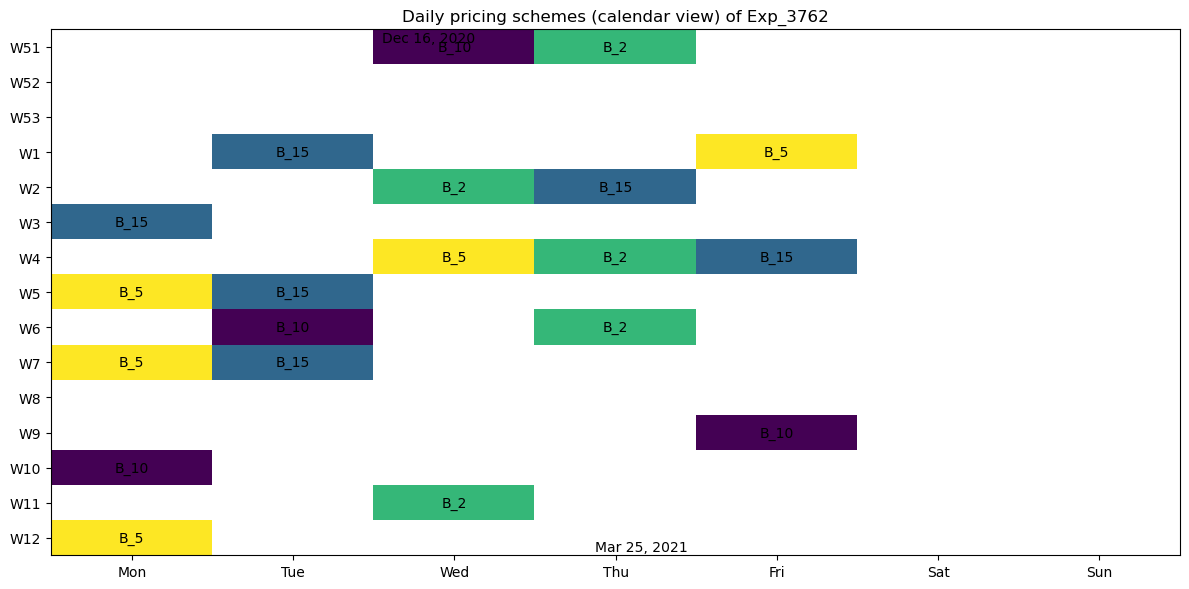

In [103]:
plot_pricing_schemes("Exp_3762")

consistent? True


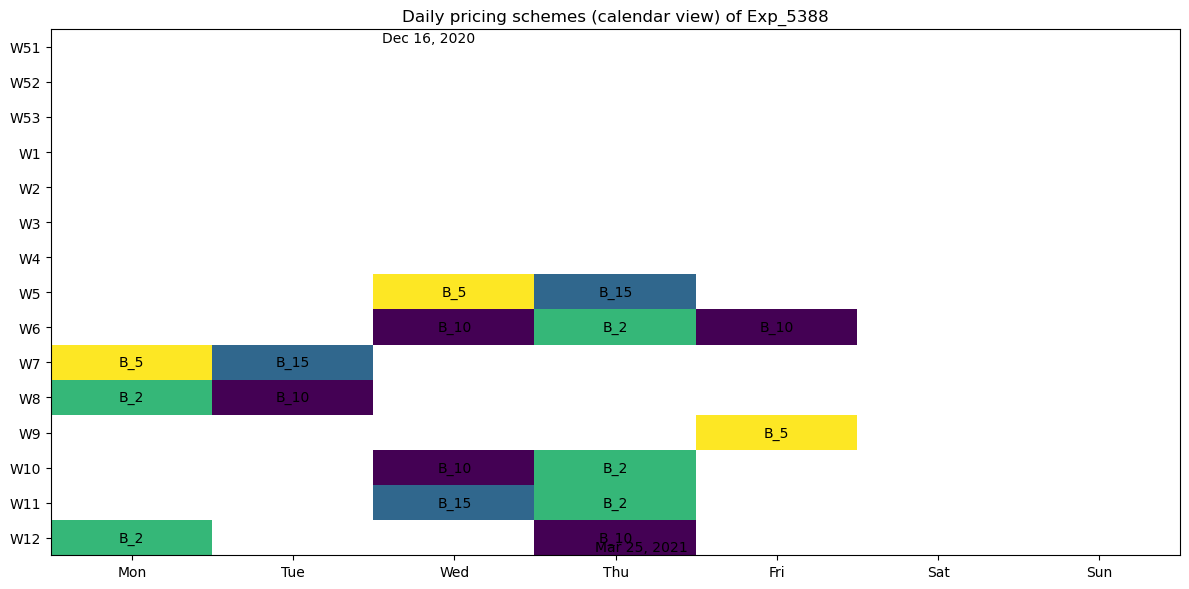

In [104]:
plot_pricing_schemes(target_id = id_list[-3])

In [105]:
# j = 0
# for id in id_list:
#     plot_pricing_schemes(id)
#     if j == 10:
#         break
#     j += 1

In [106]:
n_total = len(df_phase2)
n_non_null = df_phase2["Price_signal"].notna().sum()
print(n_non_null, n_total, n_non_null/n_total)

587184 3432672 0.1710574153312638


In [107]:
#df_phase2 = df_phase2.dropna(subset=["Price_signal"])
print(len(df_phase2))

3432672


In [108]:
import pandas as pd

df_phase2["Date"] = pd.to_datetime(df_phase2["Date"], errors="coerce")

daily_counts_long = (
    df_phase2.assign(scheme=df_phase2["Price_signal"].fillna("N"))
    .groupby(["Date", "scheme"])["ID"]
    .nunique()
    .reset_index(name="n_ids")
)

daily_counts_long_noN = daily_counts_long[daily_counts_long["scheme"] != "N"].copy()
daily_counts_long_noN.head()


,Date,scheme,n_ids
15,2020-12-16,A_5,128
16,2020-12-16,B_10,485
18,2020-12-16,P0_10,129
19,2020-12-16,P_10,126
20,2020-12-17,A_10,103


In [109]:
daily_counts_wide = (
    daily_counts_long_noN
    # daily_counts_long
    .pivot_table(index="Date", columns="scheme", values="n_ids", fill_value=0)
    .sort_index()
)

daily_counts_wide


scheme,A_10,A_5,B_10,B_15,B_2,B_5,C,P0_10,P0_2,P0_30,P_10,P_15,P_2,P_5
Date,,,,,,,,,,,,,,
2020-12-16,0.0,128.0,485.0,0.0,0.0,0.0,0.0,129.0,0.0,0.0,126.0,0.0,0.0,0.0
2020-12-17,103.0,0.0,0.0,0.0,391.0,0.0,119.0,0.0,129.0,0.0,0.0,0.0,126.0,0.0
2021-01-05,119.0,0.0,0.0,319.0,0.0,0.0,0.0,0.0,0.0,129.0,0.0,253.0,0.0,0.0
2021-01-06,0.0,0.0,0.0,73.0,0.0,0.0,0.0,0.0,0.0,0.0,103.0,128.0,0.0,0.0
2021-01-07,0.0,0.0,0.0,0.0,0.0,160.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-08,0.0,119.0,0.0,0.0,0.0,232.0,128.0,103.0,0.0,0.0,129.0,0.0,0.0,253.0
2021-01-11,103.0,0.0,0.0,73.0,216.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,127.0,126.0
2021-01-12,0.0,0.0,192.0,0.0,128.0,0.0,0.0,129.0,0.0,0.0,103.0,0.0,0.0,0.0
2021-01-13,119.0,0.0,129.0,0.0,103.0,0.0,0.0,0.0,0.0,0.0,127.0,128.0,0.0,0.0


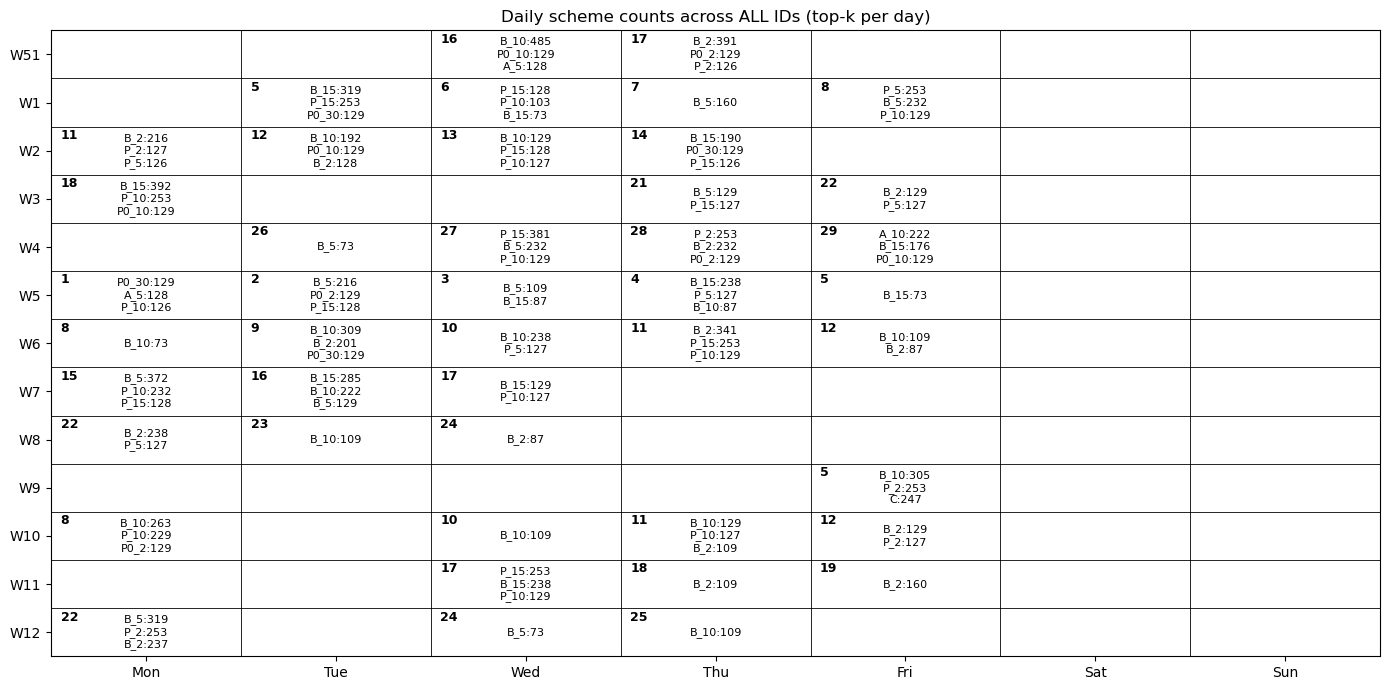

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_daily_scheme_counts_calendar(
    df_daily_wide,
    start=None,
    end=None,
    top_k=2,
):
    d = df_daily_wide.copy()
    if start is not None:
        d = d[d.index >= pd.to_datetime(start)]
    if end is not None:
        d = d[d.index <= pd.to_datetime(end)]
    if d.empty:
        print("No data in the selected window.")
        return

    dates = d.index.to_series()
    weekday = dates.dt.weekday  # Mon=0..Sun=6
    iso = dates.dt.isocalendar()
    iso_year = iso.year.astype(int)
    iso_week = iso.week.astype(int)

    weeks = (
        pd.DataFrame({"iso_year": iso_year.values, "iso_week": iso_week.values})
        .drop_duplicates()
        .sort_values(["iso_year", "iso_week"])
        .reset_index(drop=True)
    )
    weeks["row"] = np.arange(len(weeks))

    key = pd.DataFrame({
        "Date": d.index,
        "weekday": weekday.values,
        "iso_year": iso_year.values,
        "iso_week": iso_week.values,
    })
    key = key.merge(weeks, on=["iso_year", "iso_week"], how="left")

    n_rows, n_cols = len(weeks), 7
    grid = np.zeros((n_rows, n_cols))

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.imshow(grid, aspect="auto", interpolation="none", alpha=0.0)

    ax.set_xticks(range(7))
    ax.set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([f"W{w}" for w in weeks["iso_week"]])

    # ---- draw grid lines (cell borders) ----
    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="black", linewidth=0.6)
    ax.tick_params(which="minor", bottom=False, left=False)

    # ---- write date number + top-k schemes ----
    for _, r in key.iterrows():
        day = r["Date"]
        row = int(r["row"])
        col = int(r["weekday"])

        ax.text(
            col - 0.45,
            row - 0.45,
            str(day.day),
            ha="left",
            va="top",
            fontsize=9,
            fontweight="bold",
        )

        s = d.loc[day]
        s = s[s > 0].sort_values(ascending=False).head(top_k)

        if len(s) > 0:
            txt = "\n".join([f"{idx}:{int(val)}" for idx, val in s.items()])
            ax.text(col, row, txt, ha="center", va="center", fontsize=8)

    ax.set_title("Daily scheme counts across ALL IDs (top-k per day)")
    plt.tight_layout()
    plt.show()


plot_daily_scheme_counts_calendar(
    daily_counts_wide,
    # start="2021-01-01",
    # end="2021-03-25",
    top_k=3
)


## Replace price signal with real-valued prices

In [111]:
price_df = pd.read_csv("data/price_signals.csv")
price_df.head(20)

,Price_signal,Price_profile,Price_level,Hour,Experiment_price_NOK_kWh
0,A_10,A,10,1,1.00
1,A_10,A,10,2,0.99
2,A_10,A,10,3,0.95
3,A_10,A,10,4,0.95
4,A_10,A,10,5,0.96
5,A_10,A,10,6,1.00
6,A_10,A,10,7,5.48
7,A_10,A,10,8,9.95
8,A_10,A,10,9,10.13
9,A_10,A,10,10,10.06


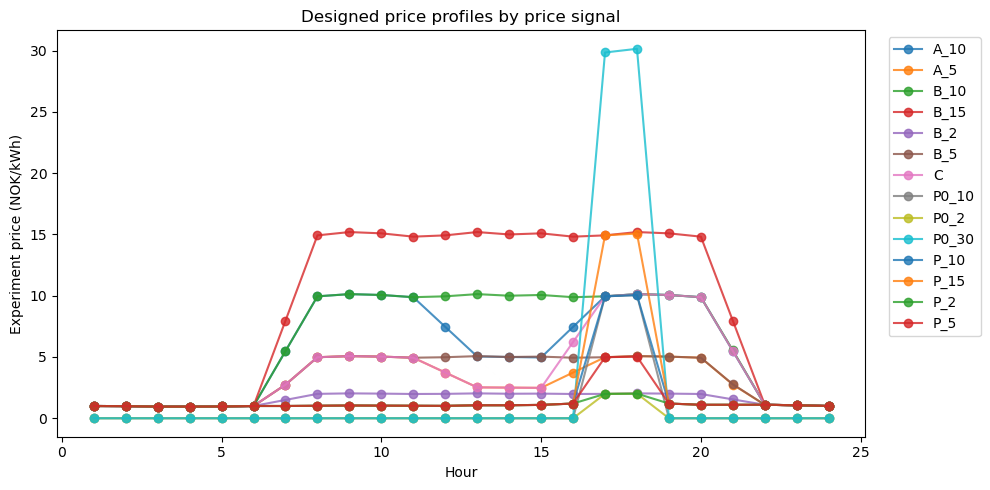

In [112]:
import matplotlib.pyplot as plt

price_df = pd.read_csv("data/price_signals.csv")

plt.figure(figsize=(10, 5))
for s, g in price_df.groupby("Price_signal"):
    plt.plot(
        g["Hour"],
        g["Experiment_price_NOK_kWh"],
        marker="o",
        label=s,
        alpha=0.8
    )

plt.xlabel("Hour")
plt.ylabel("Experiment price (NOK/kWh)")
plt.title("Designed price profiles by price signal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


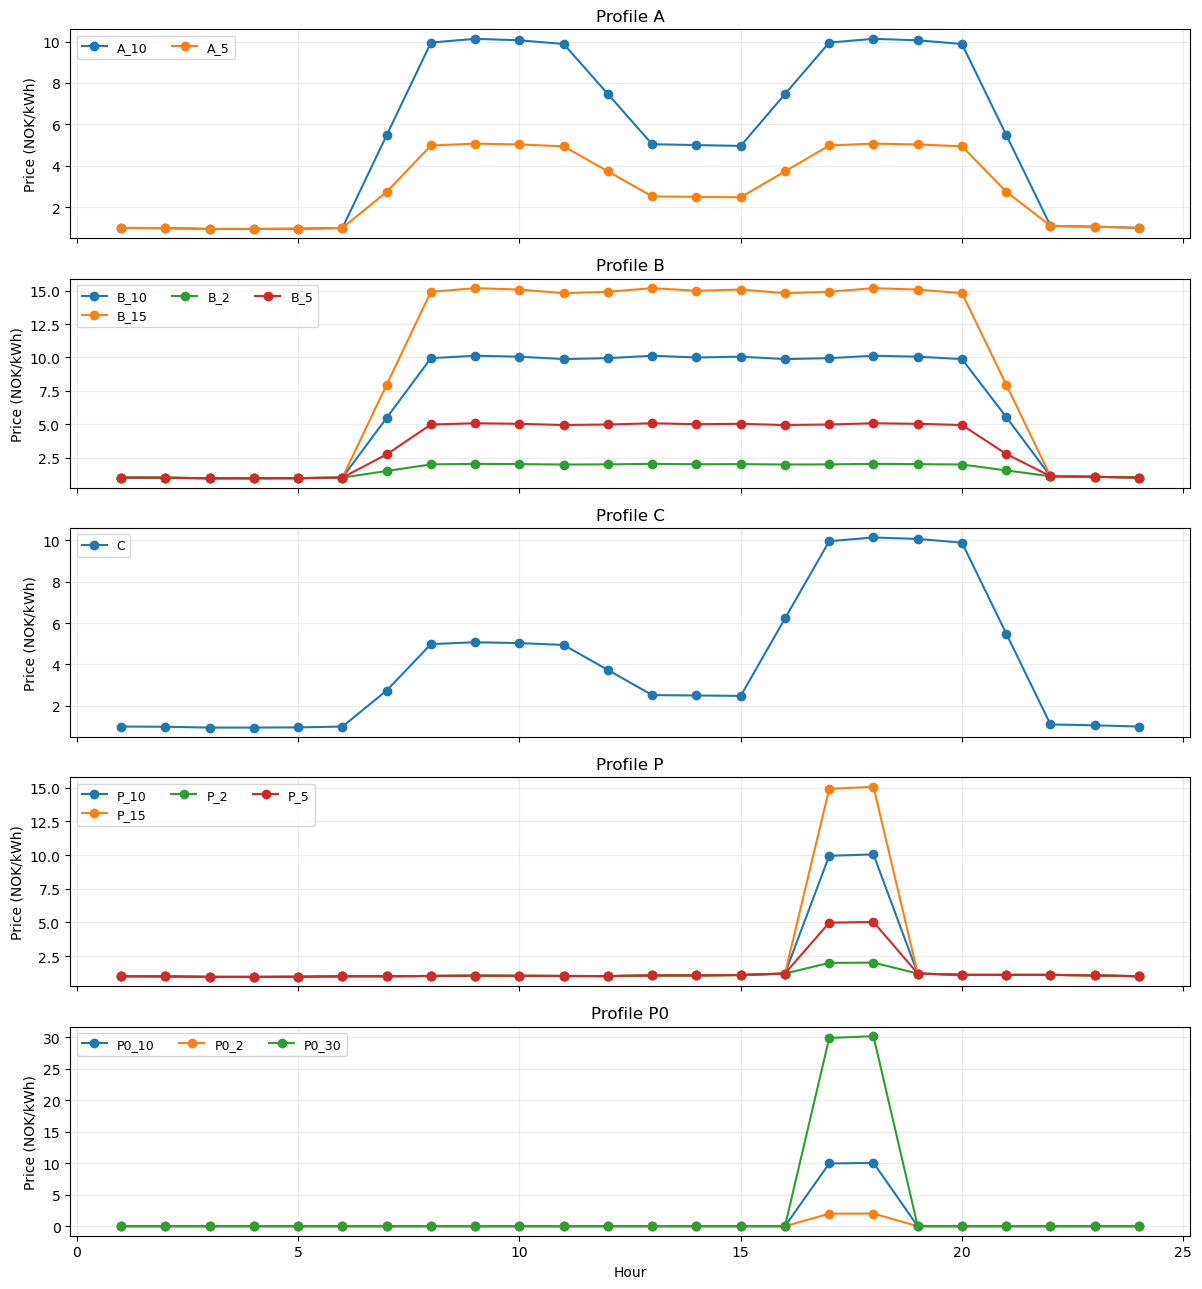

In [113]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_price_signals_by_profile(
    price_df,
    x_col="Hour",
    y_col="Experiment_price_NOK_kWh",
    profile_col="Price_profile",
    signal_col="Price_signal",
):
    # Ensure proper dtypes / ordering
    d = price_df.copy()
    d[x_col] = pd.to_numeric(d[x_col], errors="coerce")
    d[y_col] = pd.to_numeric(d[y_col], errors="coerce")


    profile_order = ["A", "B", "C", "P", "P0"]
    profiles = [p for p in profile_order if p in d[profile_col].unique()]
    profiles += [p for p in sorted(d[profile_col].dropna().unique()) if p not in profiles]

    n_rows = len(profiles)
    fig, axes = plt.subplots(n_rows, 1, sharex=True, figsize=(12, 2.6 * n_rows))

    if n_rows == 1:
        axes = [axes]

    for ax, prof in zip(axes, profiles):
        dp = d[d[profile_col] == prof].sort_values([signal_col, x_col])

        # plot each signal in this profile
        for sig, g in dp.groupby(signal_col):
            ax.plot(g[x_col], g[y_col], marker="o", linewidth=1.5, label=sig)

        ax.set_title(f"Profile {prof}")
        ax.set_ylabel("Price (NOK/kWh)")
        ax.grid(True, alpha=0.25)

        ax.legend(loc="upper left", ncol=3, fontsize=9, frameon=True)

    axes[-1].set_xlabel("Hour")
    plt.tight_layout()
    plt.show()

price_df = pd.read_csv("data/price_signals.csv")
plot_price_signals_by_profile(price_df)


## Plot demand/price

In [114]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_id_timeseries(
    df,
    id_value,
    start_time=None,
    end_time=None,
    expected_freq="1H",
    max_gap_hours=1,
):
    """
    Plot hourly demand and experimental price for a given ID
    within a specified time window.
    """

    # Filter ID
    d = df.loc[df["ID"] == id_value].copy()
    if d.empty:
        raise ValueError(f"No rows found for ID={id_value}")

    # Build timestamp
    if "From" in d.columns:
        d["time"] = pd.to_datetime(d["From"], utc=True, errors="coerce")
    else:
        d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
        d["time"] = d["Date"] + pd.to_timedelta(d["Hour"] - 1, unit="h")

    d = d.dropna(subset=["time"]).sort_values("time")

    # ---- NEW: time window filtering ----
    if start_time is not None:
        start_time = pd.to_datetime(start_time, utc=True)
        d = d[d["time"] >= start_time]

    if end_time is not None:
        end_time = pd.to_datetime(end_time, utc=True)
        d = d[d["time"] <= end_time]

    if d.empty:
        raise ValueError("No data in the specified time window.")

    # Full hourly index within the window
    full_index = pd.date_range(
        d["time"].min(),
        d["time"].max(),
        freq=expected_freq,
        tz=d["time"].dt.tz,
    )
    d = d.set_index("time").reindex(full_index)

    # Break lines at large gaps
    gap = d.index.to_series().diff().dt.total_seconds().div(3600)
    d.loc[gap > max_gap_hours, ["Demand_kWh", "Experiment_price_NOK_kWh"]] = float("nan")

    # Plot
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

    axes[0].plot(d.index, d["Demand_kWh"])
    axes[0].set_ylabel("Demand_kWh")
    axes[0].set_title(f"ID = {id_value}")

    axes[1].plot(d.index, d["Experiment_price_NOK_kWh"])
    axes[1].set_ylabel("Experiment_price")
    axes[1].set_xlabel("Time")

    plt.tight_layout()
    plt.show()


/var/folders/tv/8c44lqx96t7gq3rw3crkf68w0000gn/T/ipykernel_27569/8112804.py:44: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_index = pd.date_range(


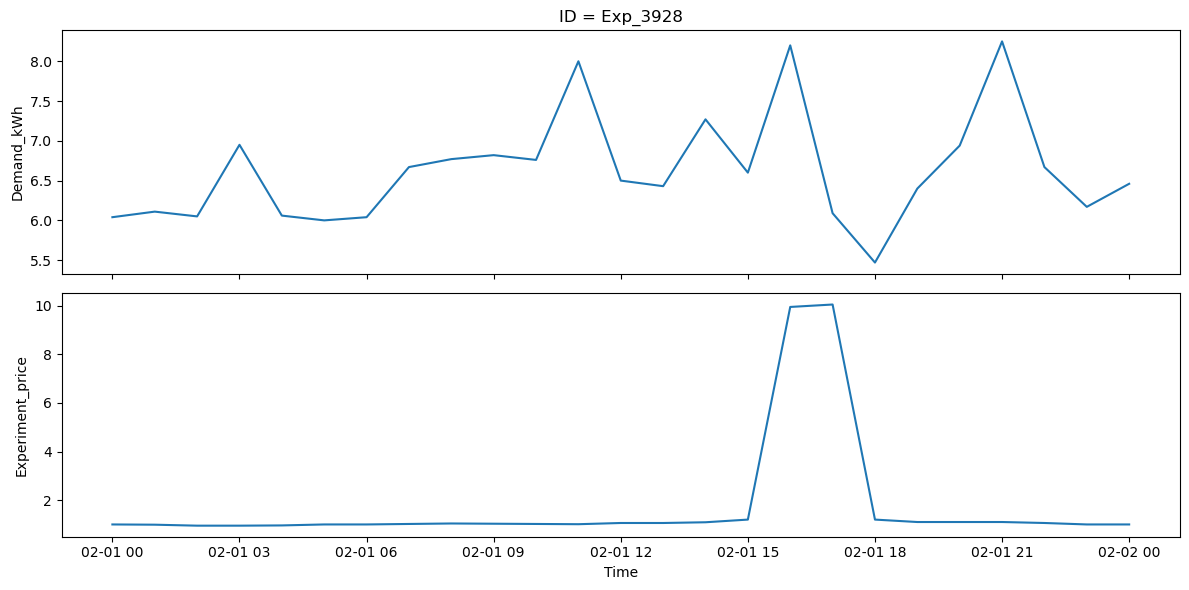

In [115]:
plot_id_timeseries(
    df_phase2,
    "Exp_3928",
    start_time="2021-02-01",
    end_time="2021-02-02",
    expected_freq="1H",
    max_gap_hours=1,
)

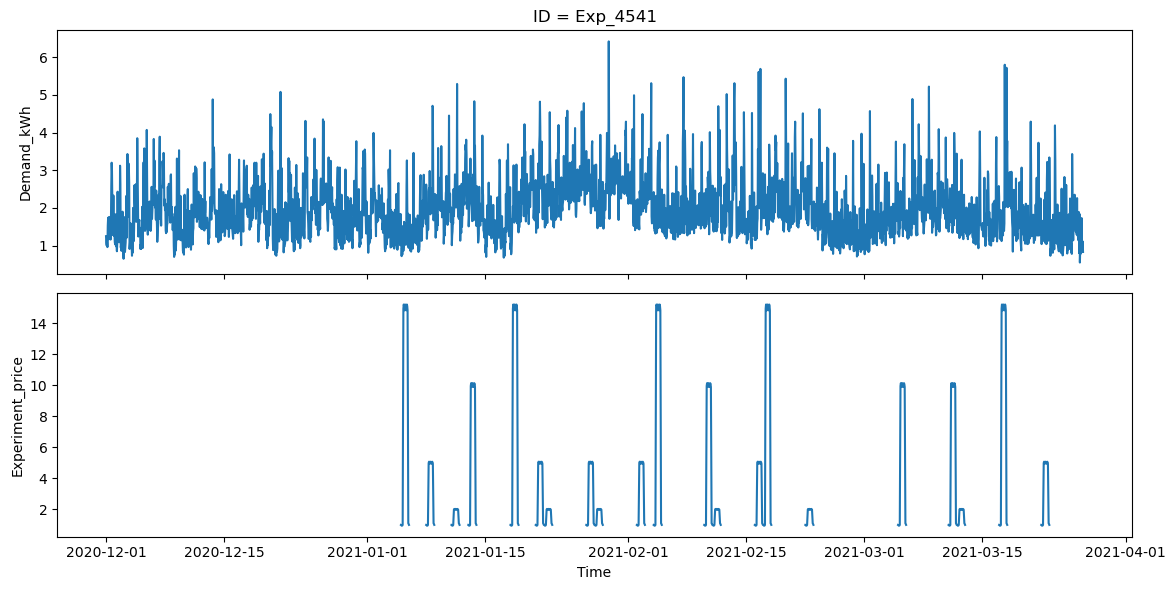

In [116]:
plot_id_timeseries(df_phase2, "Exp_4541", expected_freq="1h", max_gap_hours=1)

In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_id_timeseries_with_scheme_shading(
    df,
    id_value,
    start_time=None,
    end_time=None,
    expected_freq="1h",
    max_gap_hours=1,
    scheme_col="Price_signal",
    shade_alpha=0.18,
):
    # 1) Filter to ID and build timestamp
    d = df.loc[df["ID"] == id_value].copy()
    if d.empty:
        raise ValueError(f"No rows found for ID={id_value}")

    if "From" in d.columns:
        d["time"] = pd.to_datetime(d["From"], utc=True, errors="coerce")
    else:
        d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
        d["time"] = d["Date"] + pd.to_timedelta(d["Hour"] - 1, unit="h")

    d = d.dropna(subset=["time"]).sort_values("time")

    # 2) Window filter (inclusive)
    start_dt = pd.to_datetime(start_time, utc=True) if start_time is not None else None
    end_dt   = pd.to_datetime(end_time, utc=True) if end_time is not None else None

    if start_dt is not None:
        d = d[d["time"] >= start_dt]
    if end_dt is not None:
        d = d[d["time"] <= end_dt]

    if d.empty:
        raise ValueError("No data in the specified time window.")

    # 3) Daily scheme table (one scheme per day)
    d["scheme"] = d[scheme_col].fillna("N")
    d["day"] = d["time"].dt.floor("D")

    daily_scheme = (
        d.groupby("day")["scheme"]
        .first()
        .reset_index()
        .rename(columns={"day": "time_day"})
        .sort_values("time_day")
        .reset_index(drop=True)
    )

    # 4) Reindex hourly to expose missing hours
    full_index = pd.date_range(
        d["time"].min(),
        d["time"].max(),
        freq=expected_freq,
        tz=d["time"].dt.tz,
    )

    dh = d.set_index("time").reindex(full_index)
    dh.index.name = "time"

    # Attach daily scheme to each hour
    dh = dh.reset_index()
    dh["time_day"] = dh["time"].dt.floor("D")
    dh = dh.merge(daily_scheme, on="time_day", how="left")
    dh = dh.set_index("time")

    # 5) Break lines at large gaps (only demand/price)
    gap_hours = dh.index.to_series().diff().dt.total_seconds().div(3600)
    dh.loc[gap_hours > max_gap_hours, ["Demand_kWh", "Experiment_price_NOK_kWh"]] = np.nan

    # 6) Prepare shading blocks (contiguous scheme regions)
    schemes = [s for s in pd.Series(daily_scheme["scheme"].unique()).dropna().tolist() if s != "N"]
    cmap = plt.get_cmap("tab20")
    scheme_to_color = {s: cmap(i % cmap.N) for i, s in enumerate(sorted(schemes))}

    ds = daily_scheme.copy()
    if start_dt is not None:
        ds = ds[ds["time_day"] >= start_dt.floor("D")]
    if end_dt is not None:
        ds = ds[ds["time_day"] <= end_dt.floor("D")]
    ds = ds.sort_values("time_day").reset_index(drop=True)

    blocks = None
    if not ds.empty:
        ds["chg"] = (ds["scheme"] != ds["scheme"].shift(1)).cumsum()
        blocks = ds.groupby("chg").agg(
            scheme=("scheme", "first"),
            start=("time_day", "min"),
            end=("time_day", "max"),
        ).reset_index(drop=True)

    # 7) Plot
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

    # Demand line
    axes[0].plot(dh.index, dh["Demand_kWh"])
    axes[0].set_ylabel("Demand_kWh")
    axes[0].set_title(f"ID = {id_value}")

    # Price line
    axes[1].plot(dh.index, dh["Experiment_price_NOK_kWh"])
    axes[1].set_ylabel("Experiment_price")
    axes[1].set_xlabel("Time")

    # Shade BOTH axes, no text labels
    if blocks is not None:
        for _, b in blocks.iterrows():
            if b["scheme"] == "N" or pd.isna(b["scheme"]):
                continue
            x0 = pd.Timestamp(b["start"]).to_pydatetime()
            x1 = (pd.Timestamp(b["end"]) + pd.Timedelta(days=1)).to_pydatetime()
            color = scheme_to_color.get(b["scheme"], "grey")

            for ax in axes:  # apply to both demand & price axes
                ax.axvspan(x0, x1, alpha=shade_alpha, color=color)

    plt.tight_layout()
    plt.show()
    return dh


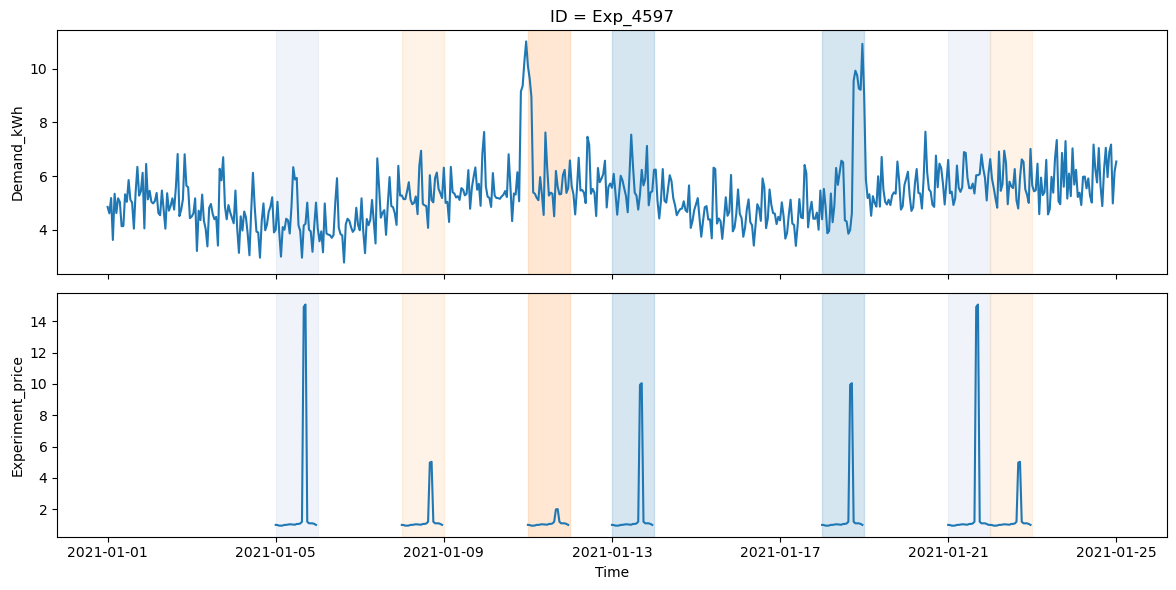

In [118]:
# Example
_ = plot_id_timeseries_with_scheme_shading(
    df_phase2,
    "Exp_4597",
    start_time="2021-01-01",
    end_time="2021-01-25",
)

## Clustering

In [137]:
df_phase2

,ID,From,Date,Hour,Participation_Phase,Demand_kWh,Price_signal,Experiment_price_NOK_kWh,Temperature,Temperature24,Temperature48,Temperature72
3250992,Exp_3928,2020-12-01T00:00:00Z,2020-12-01,1,Phase_2,4.430,NaN,NaN,4.2,0.7,-0.8,-1.3
3250993,Exp_3928,2020-12-01T01:00:00Z,2020-12-01,2,Phase_2,4.500,NaN,NaN,4.2,1.0,-0.7,-1.2
3250994,Exp_3928,2020-12-01T02:00:00Z,2020-12-01,3,Phase_2,5.440,NaN,NaN,3.9,1.3,-0.6,-1.0
3250995,Exp_3928,2020-12-01T03:00:00Z,2020-12-01,4,Phase_2,4.500,NaN,NaN,3.1,1.6,-0.5,-0.9
3250996,Exp_3928,2020-12-01T04:00:00Z,2020-12-01,5,Phase_2,4.480,NaN,NaN,2.4,1.8,-0.4,-0.8
...,...,...,...,...,...,...,...,...,...,...,...,...
13482187,Exp_5388,2021-03-26T19:00:00Z,2021-03-26,20,Phase_2,0.278,NaN,NaN,7.5,4.7,3.9,4.6
13482188,Exp_5388,2021-03-26T20:00:00Z,2021-03-26,21,Phase_2,0.427,NaN,NaN,7.3,4.9,4.0,4.6
13482189,Exp_5388,2021-03-26T21:00:00Z,2021-03-26,22,Phase_2,0.304,NaN,NaN,7.5,5.2,4.1,4.7
13482190,Exp_5388,2021-03-26T22:00:00Z,2021-03-26,23,Phase_2,0.390,NaN,NaN,7.4,5.4,4.1,4.8


In [138]:
# Ensure numeric type (optional but safe)
df_phase2["Demand_kWh"] = pd.to_numeric(df_phase2["Demand_kWh"], errors="coerce")

# 1) Keep only baseline rows: Price_signal is NaN
df_base = df_phase2[df_phase2["Price_signal"].isna()].copy()

# 2) Compute baseline demand: mean Demand_kWh by (Hour, ID)
baseline = (
    df_base
    .groupby(["Hour", "ID"], as_index=False)["Demand_kWh"]
    .mean()
    .rename(columns={"Demand_kWh": "baseline_demand"})
)

# 3) Split into 24 DataFrames (hour=1..24)
df_by_hour_baseline = {
    h: baseline[baseline["Hour"] == h][["ID", "baseline_demand"]].reset_index(drop=True)
    for h in range(1, 25)
}

# Example: hour 1 baseline table
df_by_hour_baseline[1].head()


,ID,baseline_demand
0,Exp_1724,2.965521
1,Exp_1725,3.769375
2,Exp_1729,2.903542
3,Exp_1731,0.370417
4,Exp_1735,2.932187


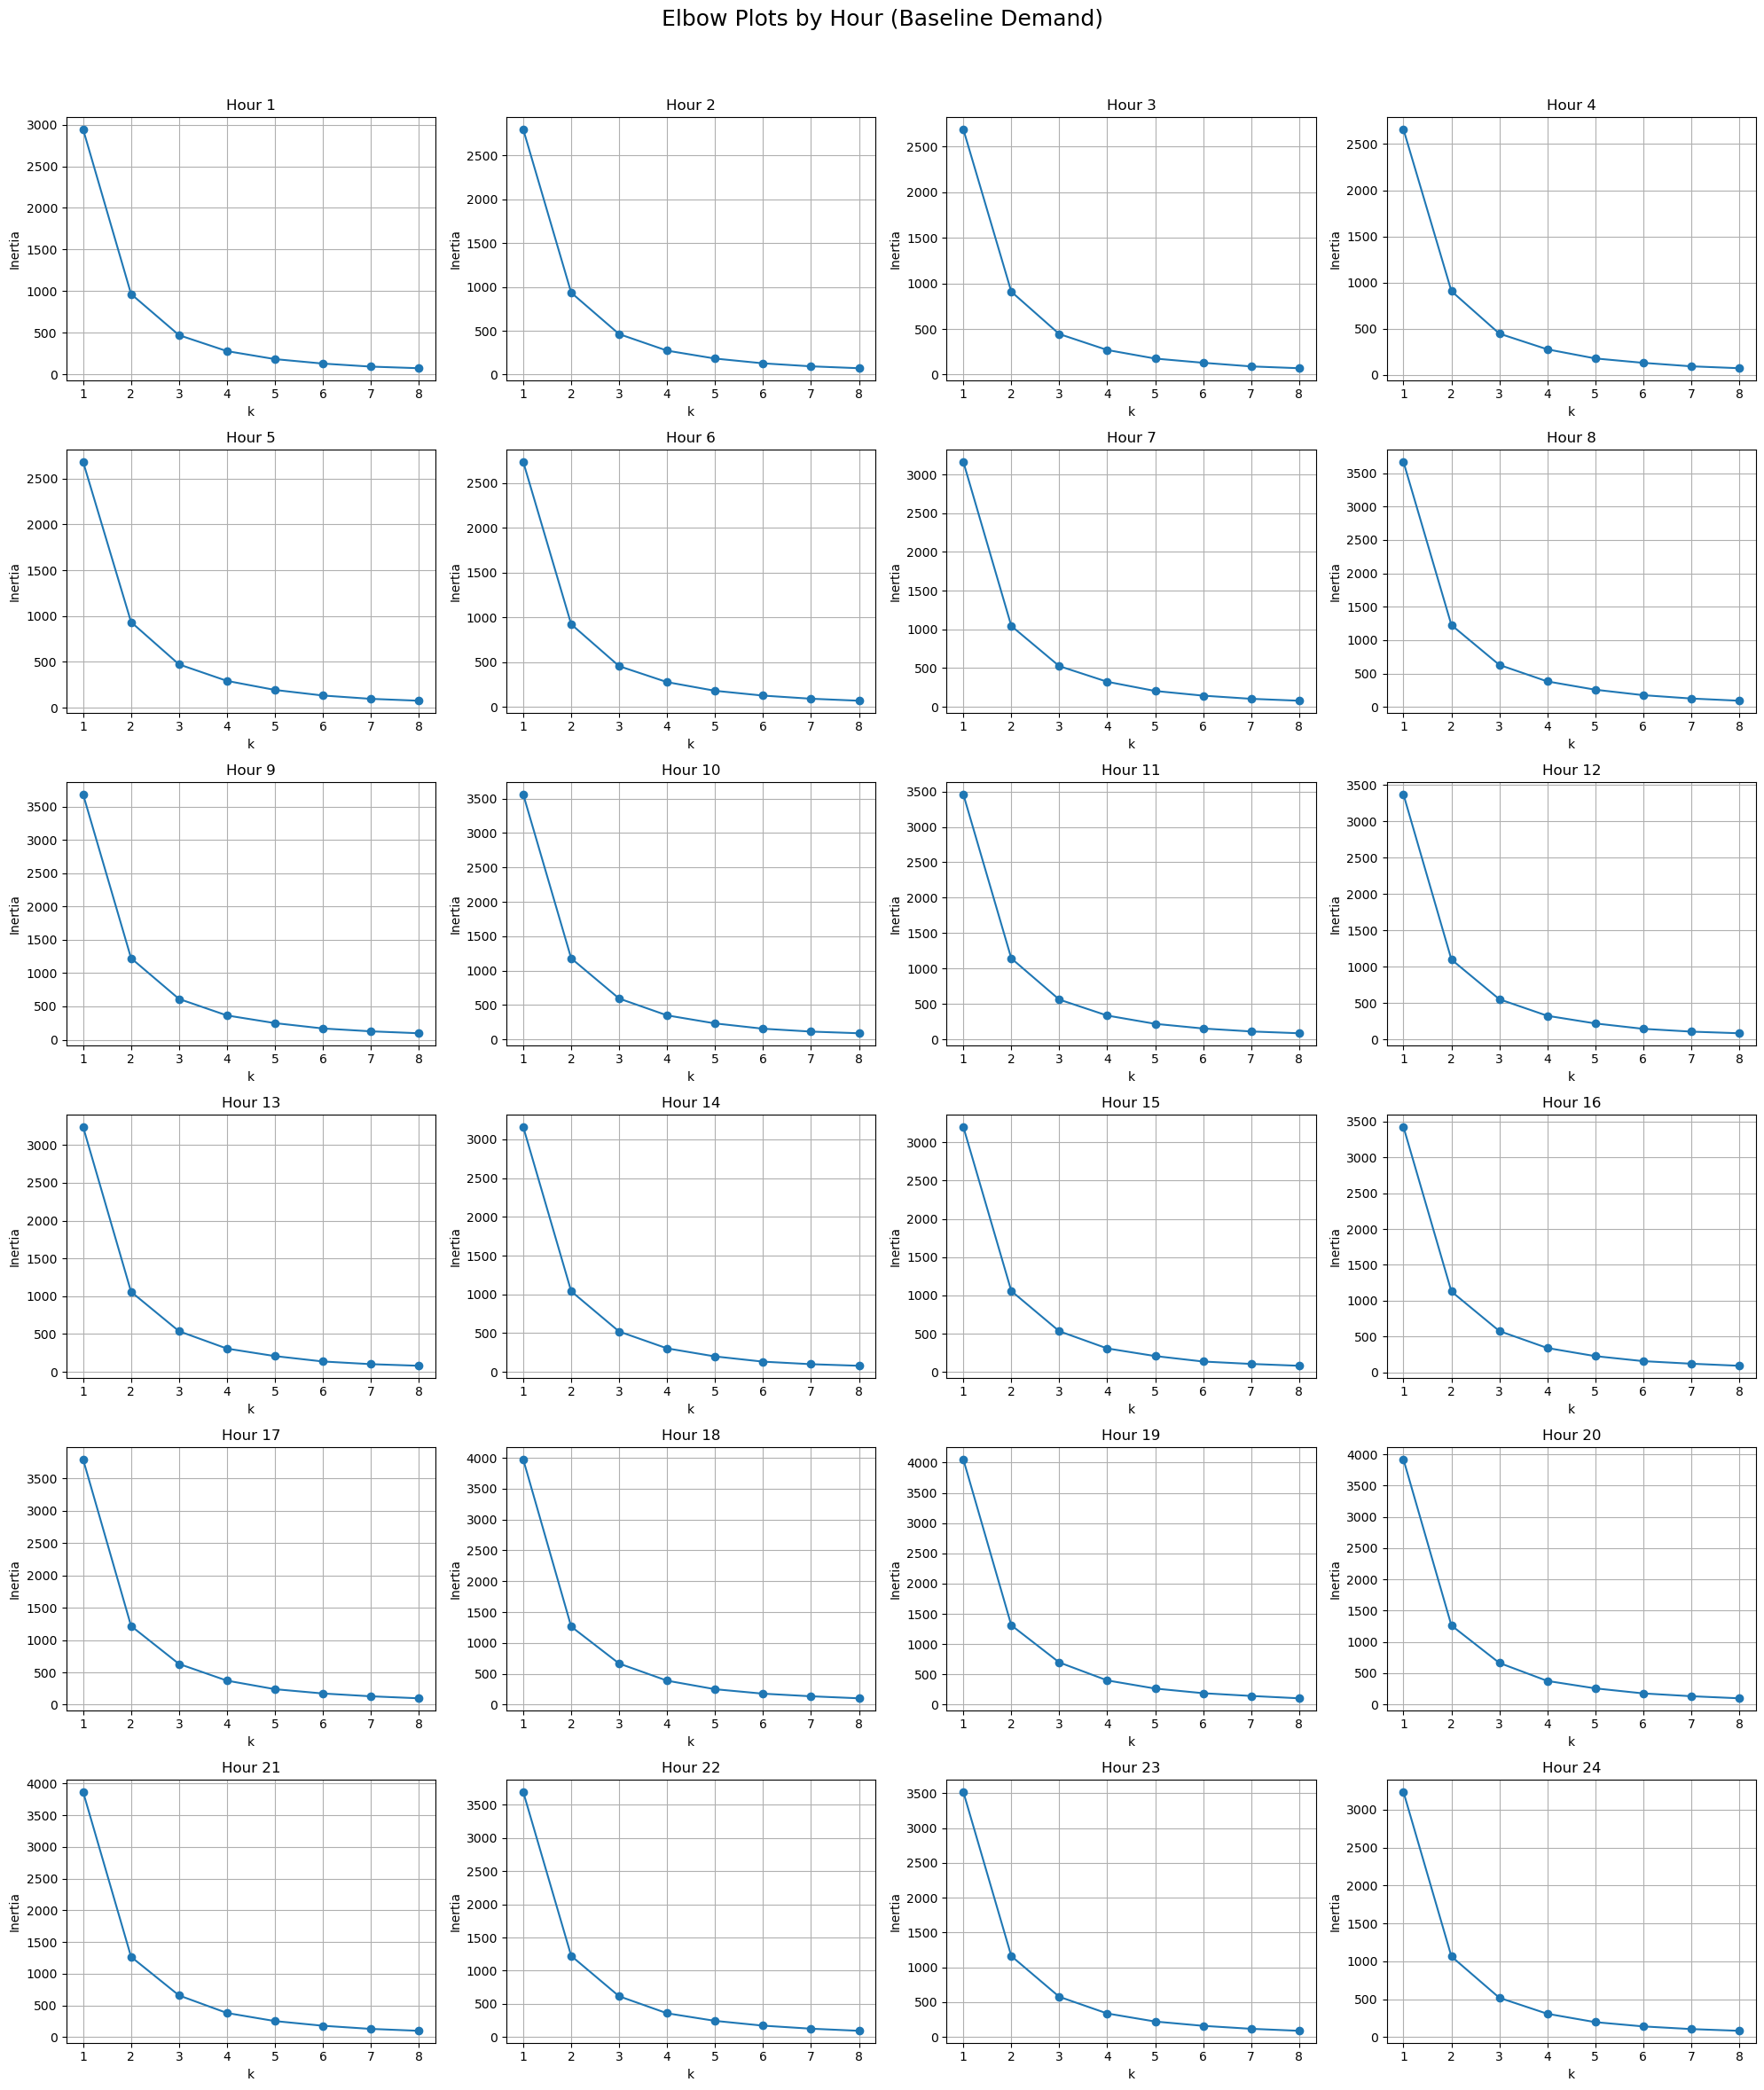

In [139]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

# Set maximum number of clusters to test
max_k = 8

# Create 6x4 subplot grid
fig, axes = plt.subplots(6, 4, figsize=(20, 24))
axes = axes.flatten()

for idx, h in enumerate(range(1, 25)):
    ax = axes[idx]
    df_h = df_by_hour_baseline[h]

    # Drop NaNs
    X = df_h[["baseline_demand"]].dropna().values

    # Skip if not enough observations
    if len(X) < max_k:
        ax.set_title(f"Hour {h} (n={len(X)})")
        ax.text(0.5, 0.5, "Not enough data",
                ha="center", va="center", transform=ax.transAxes)
        continue

    inertias = []

    for k in range(1, max_k + 1):
        kmeans = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    ax.plot(range(1, max_k + 1), inertias, marker="o")
    ax.set_title(f"Hour {h}")
    ax.set_xlabel("k")
    ax.set_ylabel("Inertia")
    ax.grid(True)

# Overall title
fig.suptitle("Elbow Plots by Hour (Baseline Demand)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [169]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

cluster_stats_by_hour = {}

for h in range(1, 25):
    df_h = df_by_hour_baseline[h].copy()

    # Drop missing baseline demand
    df_h = df_h.dropna(subset=["baseline_demand"])

    if len(df_h) < 3:
        print(f"Hour {h}: not enough IDs (n={len(df_h)})")
        df_by_hour_baseline[h] = df_h
        continue

    # Fit KMeans (k=3)
    X = df_h[["baseline_demand"]].values
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_h["cluster_raw"] = kmeans.fit_predict(X)

    # Order clusters by mean baseline demand (D_bar)
    means = (
        df_h.groupby("cluster_raw")["baseline_demand"]
        .mean()
        .sort_values()
    )

    # Map to {1,2,3} instead of {0,1,2}
    label_map = {
        old_label: new_label + 1
        for new_label, old_label in enumerate(means.index)
    }

    # Final cluster label
    df_h["cluster"] = df_h["cluster_raw"].map(label_map).astype(int)

    # Save hour-level DataFrame
    df_by_hour_baseline[h] = (
        df_h[["ID", "baseline_demand", "cluster"]]
        .reset_index(drop=True)
    )

    # Cluster statistics
    stats = (
        df_h.groupby("cluster")["baseline_demand"]
        .agg(
            count="count",
            mean="mean",
            std="std",
            min="min",
            q25=lambda x: x.quantile(0.25),
            median="median",
            q75=lambda x: x.quantile(0.75),
            max="max",
        )
        .reset_index()
    )

    stats.insert(0, "Hour", h)
    cluster_stats_by_hour[h] = stats

# Combine all hours (optional)
cluster_stats_all = pd.concat(cluster_stats_by_hour.values(), ignore_index=True)

In [170]:
cluster_stats_by_hour[1]

,Hour,cluster,count,mean,std,min,q25,median,q75,max
0,1,1,529,0.848064,0.478477,0.034896,0.417187,0.844842,1.261667,1.688438
1,1,2,470,2.531901,0.525740,1.701750,2.083052,2.472865,2.929245,3.612396
2,1,3,234,4.692877,0.974631,3.627292,3.958880,4.432137,5.104479,8.810309


In [171]:
df_by_hour_baseline

{1:             ID  baseline_demand  cluster
 0     Exp_1724         2.965521        2
 1     Exp_1725         3.769375        3
 2     Exp_1729         2.903542        2
 3     Exp_1731         0.370417        1
 4     Exp_1735         2.932187        2
 ...        ...              ...      ...
 1228  Exp_5379         3.840500        3
 1229  Exp_5386         2.666090        2
 1230  Exp_5388         0.520150        1
 1231  Exp_5392         4.159300        3
 1232  Exp_5406         0.887920        1
 
 [1233 rows x 3 columns],
 2:             ID  baseline_demand  cluster
 0     Exp_1724         2.914583        2
 1     Exp_1725         3.694583        3
 2     Exp_1729         2.868750        2
 3     Exp_1731         0.370521        1
 4     Exp_1735         2.697812        2
 ...        ...              ...      ...
 1228  Exp_5379         3.653980        3
 1229  Exp_5386         2.484250        2
 1230  Exp_5388         0.507460        1
 1231  Exp_5392         3.717080        3


## Filtering

In [148]:
# Keep only rows where Price_signal is NOT NaN
df_phase2_price = df_phase2[df_phase2["Price_signal"].notna()].copy()

In [152]:
print(df_phase2_price)

                ID                  From       Date  Hour Participation_Phase  \
3251352   Exp_3928  2020-12-16T00:00:00Z 2020-12-16     1             Phase_2   
3251353   Exp_3928  2020-12-16T01:00:00Z 2020-12-16     2             Phase_2   
3251354   Exp_3928  2020-12-16T02:00:00Z 2020-12-16     3             Phase_2   
3251355   Exp_3928  2020-12-16T03:00:00Z 2020-12-16     4             Phase_2   
3251356   Exp_3928  2020-12-16T04:00:00Z 2020-12-16     5             Phase_2   
...            ...                   ...        ...   ...                 ...   
13482163  Exp_5388  2021-03-25T19:00:00Z 2021-03-25    20             Phase_2   
13482164  Exp_5388  2021-03-25T20:00:00Z 2021-03-25    21             Phase_2   
13482165  Exp_5388  2021-03-25T21:00:00Z 2021-03-25    22             Phase_2   
13482166  Exp_5388  2021-03-25T22:00:00Z 2021-03-25    23             Phase_2   
13482167  Exp_5388  2021-03-25T23:00:00Z 2021-03-25    24             Phase_2   

          Demand_kWh Price_

In [153]:
# Extract cluster mean baseline demand by (Hour, cluster)
cluster_mean = (
    cluster_stats_all[["Hour", "cluster", "mean"]]
    .rename(columns={"mean": "cluster_mean_baseline"})
)


In [154]:
# Concatenate hour-level baseline DF into one
baseline_all = pd.concat(
    [
        df.assign(Hour=h)
        for h, df in df_by_hour_baseline.items()
    ],
    ignore_index=True
)

# Merge cluster label to price data
df_phase2_price = df_phase2_price.merge(
    baseline_all[["ID", "Hour", "cluster"]],
    on=["ID", "Hour"],
    how="left"
)


In [155]:
df_phase2_price = df_phase2_price.merge(
    cluster_mean,
    on=["Hour", "cluster"],
    how="left"
)


In [156]:
# Keep only rows where demand is NOT larger than cluster mean
df_phase2_price_filtered = df_phase2_price[
    df_phase2_price["Demand_kWh"] <= df_phase2_price["cluster_mean_baseline"]
].copy()


In [157]:
# How many rows dropped?
len(df_phase2_price) - len(df_phase2_price_filtered)

# Verify condition
(
    df_phase2_price_filtered["Demand_kWh"]
    > df_phase2_price_filtered["cluster_mean_baseline"]
).sum()


0

## Estimation

In [164]:
import pandas as pd
import statsmodels.api as sm

results = []

for h in range(1, 25):
    df_h = df_phase2_price_filtered[df_phase2_price_filtered["Hour"] == h]

    # Drop rows with missing values
    df_h = df_h.dropna(subset=["Demand_kWh", "Experiment_price_NOK_kWh"])

    # Skip if too few observations
    if len(df_h) < 10:
        print(f"Hour {h}: not enough observations (n={len(df_h)})")
        continue

    # Regressor: -Demand_kWh
    X = -df_h["Demand_kWh"]
    X = sm.add_constant(X)  # adds intercept

    y = df_h["Experiment_price_NOK_kWh"]

    # OLS
    model = sm.OLS(y, X).fit()

    a = model.params["Demand_kWh"]
    b = model.params["const"]

    p_a = model.pvalues["Demand_kWh"]
    p_b = model.pvalues["const"]

    results.append({
        "Hour": h,
        "a": a,
        "p_value_a": p_a,
        "b": b,
        "p_value_b": p_b,
        "n_obs": len(df_h)
    })


In [176]:
df_phase2

,ID,From,Date,Hour,Participation_Phase,Demand_kWh,Price_signal,Experiment_price_NOK_kWh,Temperature,Temperature24,Temperature48,Temperature72
3250992,Exp_3928,2020-12-01T00:00:00Z,2020-12-01,1,Phase_2,4.430,NaN,NaN,4.2,0.7,-0.8,-1.3
3250993,Exp_3928,2020-12-01T01:00:00Z,2020-12-01,2,Phase_2,4.500,NaN,NaN,4.2,1.0,-0.7,-1.2
3250994,Exp_3928,2020-12-01T02:00:00Z,2020-12-01,3,Phase_2,5.440,NaN,NaN,3.9,1.3,-0.6,-1.0
3250995,Exp_3928,2020-12-01T03:00:00Z,2020-12-01,4,Phase_2,4.500,NaN,NaN,3.1,1.6,-0.5,-0.9
3250996,Exp_3928,2020-12-01T04:00:00Z,2020-12-01,5,Phase_2,4.480,NaN,NaN,2.4,1.8,-0.4,-0.8
...,...,...,...,...,...,...,...,...,...,...,...,...
13482187,Exp_5388,2021-03-26T19:00:00Z,2021-03-26,20,Phase_2,0.278,NaN,NaN,7.5,4.7,3.9,4.6
13482188,Exp_5388,2021-03-26T20:00:00Z,2021-03-26,21,Phase_2,0.427,NaN,NaN,7.3,4.9,4.0,4.6
13482189,Exp_5388,2021-03-26T21:00:00Z,2021-03-26,22,Phase_2,0.304,NaN,NaN,7.5,5.2,4.1,4.7
13482190,Exp_5388,2021-03-26T22:00:00Z,2021-03-26,23,Phase_2,0.390,NaN,NaN,7.4,5.4,4.1,4.8


In [165]:
ols_results_by_hour = pd.DataFrame(results)

In [166]:
for _, row in ols_results_by_hour.iterrows():
    print(
        f"Hour {int(row['Hour'])}: "
        f"a={row['a']:.4f} (p={row['p_value_a']:.4g}), "
        f"b={row['b']:.4f} (p={row['p_value_b']:.4g})"
    )


Hour 1: a=-0.0120 (p=2.656e-08), b=0.8787 (p=0)
Hour 2: a=-0.0131 (p=2.649e-09), b=0.8718 (p=0)
Hour 3: a=-0.0103 (p=1.841e-06), b=0.8385 (p=0)
Hour 4: a=-0.0137 (p=2.417e-10), b=0.8354 (p=0)
Hour 5: a=-0.0111 (p=2.896e-07), b=0.8484 (p=0)
Hour 6: a=-0.0109 (p=1.851e-06), b=0.8814 (p=0)
Hour 7: a=-0.0102 (p=0.565), b=2.7736 (p=0)
Hour 8: a=0.0129 (p=0.6917), b=4.7396 (p=0)
Hour 9: a=0.0118 (p=0.7104), b=4.8583 (p=0)
Hour 10: a=-0.0654 (p=0.033), b=4.7988 (p=0)
Hour 11: a=-0.0500 (p=0.09205), b=4.7159 (p=0)
Hour 12: a=0.0296 (p=0.3133), b=4.6122 (p=0)
Hour 13: a=-0.0170 (p=0.5787), b=4.4480 (p=0)
Hour 14: a=-0.0329 (p=0.2798), b=4.3745 (p=0)
Hour 15: a=-0.0488 (p=0.1121), b=4.4355 (p=0)
Hour 16: a=-0.0379 (p=0.1912), b=4.6675 (p=0)
Hour 17: a=0.1535 (p=9.814e-06), b=8.8911 (p=0)
Hour 18: a=0.1630 (p=1.909e-06), b=9.0803 (p=0)
Hour 19: a=-0.0158 (p=0.5869), b=5.1537 (p=0)
Hour 20: a=-0.0338 (p=0.2466), b=5.0511 (p=0)
Hour 21: a=-0.0236 (p=0.119), b=2.9328 (p=0)
Hour 22: a=-0.0113 (p=2.59

In [172]:
cluster_stats_by_hour[17]

,Hour,cluster,count,mean,std,min,q25,median,q75,max
0,17,1,512,1.206661,0.595532,0.091979,0.682503,1.248438,1.717188,2.204063
1,17,2,481,3.192545,0.624355,2.204970,2.642526,3.185104,3.717188,4.366289
2,17,3,240,5.530946,1.046066,4.371354,4.792507,5.216380,5.953617,10.793333


In [173]:
cluster_stats_by_hour[18]

,Hour,cluster,count,mean,std,min,q25,median,q75,max
0,18,1,514,1.251026,0.599739,0.098437,0.712786,1.295340,1.763490,2.267158
1,18,2,488,3.289741,0.654965,2.272083,2.685924,3.270263,3.849727,4.501684
2,18,3,231,5.720928,1.087496,4.513333,4.937292,5.427292,6.172253,10.115625


In [174]:
514+488+231

1233

In [175]:
9.08 - 0.1639 * 1.251026

8.8749568386

In [179]:
### with Temperature

In [177]:
import pandas as pd
import statsmodels.api as sm

results = []

for h in range(1, 25):
    df_h = df_phase2_price_filtered[df_phase2_price_filtered["Hour"] == h]

    # Drop rows with missing values
    df_h = df_h.dropna(
        subset=["Demand_kWh", "Experiment_price_NOK_kWh", "Temperature"]
    )

    # Skip if too few observations
    if len(df_h) < 10:
        print(f"Hour {h}: not enough observations (n={len(df_h)})")
        continue

    # Regressors:
    # 1) -Demand_kWh
    # 2) Temperature
    X = pd.DataFrame({
        "neg_Demand_kWh": -df_h["Demand_kWh"],
        "Temperature": df_h["Temperature"]
    })

    X = sm.add_constant(X)  # adds intercept

    y = df_h["Experiment_price_NOK_kWh"]

    # OLS
    model = sm.OLS(y, X).fit()

    # Coefficients
    a = model.params["neg_Demand_kWh"]
    c = model.params["Temperature"]
    b = model.params["const"]

    # p-values
    p_a = model.pvalues["neg_Demand_kWh"]
    p_c = model.pvalues["Temperature"]
    p_b = model.pvalues["const"]

    results.append({
        "Hour": h,
        "a": a,
        "p_value_a": p_a,
        "c_temp": c,
        "p_value_temp": p_c,
        "b": b,
        "p_value_b": p_b,
        "n_obs": len(df_h)
    })


In [178]:
ols_results_by_hour = pd.DataFrame(results)


In [180]:
for _, row in ols_results_by_hour.iterrows():
    print(
        f"Hour {int(row['Hour'])}: "
        f"a={row['a']:.4f} (p={row['p_value_a']:.4g}), "
        f"b={row['b']:.4f} (p={row['p_value_b']:.4g})"
        f"T={row['c_temp']:.4f} (p={row['p_value_temp']:.4g}), "
    )


Hour 1: a=-0.0120 (p=3.47e-08), T=0.0004 (p=0.4906), b=0.8804 (p=0)
Hour 2: a=-0.0129 (p=5.277e-09), T=0.0007 (p=0.2349), b=0.8748 (p=0)
Hour 3: a=-0.0104 (p=1.672e-06), T=-0.0003 (p=0.6641), b=0.8374 (p=0)
Hour 4: a=-0.0138 (p=2.239e-10), T=-0.0003 (p=0.6698), b=0.8342 (p=0)
Hour 5: a=-0.0110 (p=4.502e-07), T=0.0003 (p=0.6064), b=0.8499 (p=0)
Hour 6: a=-0.0108 (p=2.868e-06), T=0.0004 (p=0.6016), b=0.8831 (p=0)
Hour 7: a=-0.0078 (p=0.6612), T=0.0058 (p=0.2822), b=2.8017 (p=0)
Hour 8: a=0.0213 (p=0.518), T=0.0206 (p=0.04988), b=4.8413 (p=0)
Hour 9: a=0.0109 (p=0.7337), T=-0.0027 (p=0.789), b=4.8463 (p=0)
Hour 10: a=-0.0802 (p=0.009138), T=-0.0504 (p=1.41e-08), b=4.6055 (p=0)
Hour 11: a=-0.0570 (p=0.05485), T=-0.0410 (p=8.777e-07), b=4.5841 (p=0)
Hour 12: a=0.0211 (p=0.4717), T=-0.0597 (p=7.702e-14), b=4.4709 (p=0)
Hour 13: a=-0.0196 (p=0.5203), T=-0.0803 (p=3.741e-23), b=4.3336 (p=0)
Hour 14: a=-0.0282 (p=0.351), T=-0.0912 (p=6.906e-29), b=4.2937 (p=0)
Hour 15: a=-0.0386 (p=0.2059), T=-

In [181]:
## Income

In [182]:
survey3_answers = pd.read_csv("data/survey3_answers.csv")

In [186]:
df_cluster = df_by_hour_baseline[18]
df_characteristics = (
    df_cluster
    .merge(
        survey3_answers[["ID", "Q13"]],
        on="ID",
        how="left"
    )
)

In [187]:
def income_group_q13(x):
    if pd.isna(x):
        return None
    if "300 000 - 499 999" in x:
        return "300–499k"
    elif "500 000 - 799 999" in x:
        return "500–799k"
    elif "800 000 - 999 999" in x:
        return "800–999k"
    elif "1 000 000 - 1 499 999" in x:
        return "1.0–1.5M"
    elif "1 500 000" in x:
        return "≥1.5M"
    else:
        return None


In [188]:
df_characteristics["income_group"] = (
    df_characteristics["Q13"].apply(income_group_q13)
)


In [189]:
income_dist_region = (
    df_characteristics
    .groupby(["cluster", "income_group"])
    .size()
    .unstack(fill_value=0)
)


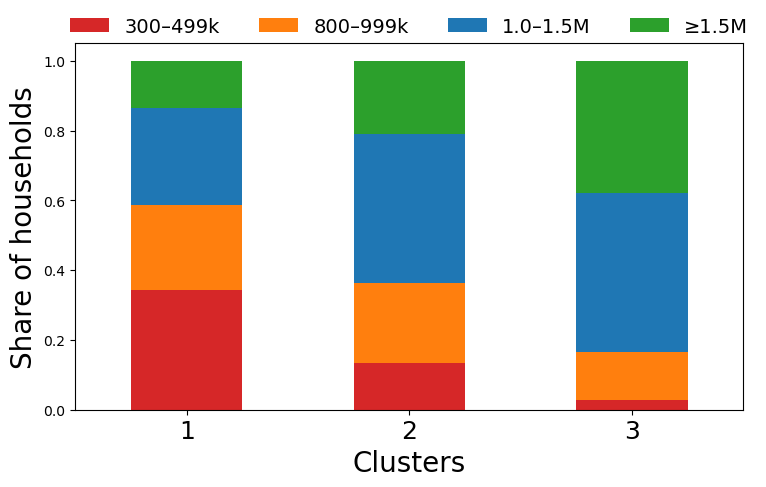

In [191]:
fig, ax = plt.subplots(figsize=(8, 5))

income_order = [
    "300–499k",
    "800–999k",
    "1.0–1.5M",
    "≥1.5M",
]


income_share_region = (
    income_dist_region
    .div(income_dist_region.sum(axis=1), axis=0)
)

income_share_region = income_share_region[income_order]

income_share_region.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=['tab:red', 'tab:orange', 'tab:blue', 'tab:green']
)

ax.set_ylabel("Share of households", fontsize=20)
ax.set_xlabel("Clusters", fontsize=20)

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12),
    ncol=4,
    frameon=False,
    fontsize=14,
    title_fontsize=13
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=18)

plt.tight_layout()
plt.show()
